# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


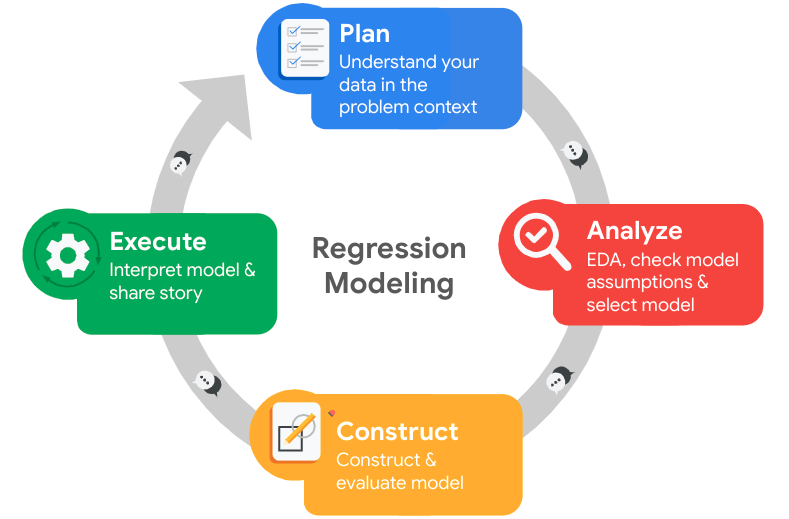

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




Who are your stakeholders for this project? The primary stakeholders are the Salifort Motors Senior Management team, the Human Resources (HR) Department, and the Team Managers who are responsible for employee retention and organizational health.

What are you trying to solve or accomplish? The goal is to analyze a dataset of employees to identify the key factors driving turnover (attrition). Ultimately, I aim to build a predictive model that can determine whether an employee is likely to leave the company, allowing the leadership to take proactive measures to improve retention.

What are your initial observations when you explore the data? The dataset contains 14,999 rows and 10 columns. Initial observations show that employees who left the company (left=1) seem to have lower satisfaction levels and higher average monthly hours. There is also a notable pattern where employees with very high project counts (7 projects) have a significantly higher turnover rate. The data appears clean but requires column renaming for better accessibility in Python.

What resources do you find yourself using as you complete this stage?

Pandas Documentation (For initial data exploration)

Google Advanced Data Analytics Professional Certificate - Course 7 Materials

Python Data Science Handbook (For structuring the analysis)

Do you have any ethical considerations in this stage? Yes. Employee data is sensitive. We must ensure that the model is used to help and support employees (e.g., reducing workload) rather than to monitor or discriminate against those flagged as "likely to leave." It is also crucial to ensure that the data is anonymized and that no personal bias is introduced into the modeling process based on department or salary.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [5]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
print(df0.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [6]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [8]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [9]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [10]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns={
    'Work_accident': 'work_accident',
    'Department': 'department',
    'time_spend_company': 'tenure',
    'average_monthly_hours': 'average_monthly_hours',
    'promotion_last_5years': 'promotion_last_5years'
})
# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [11]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [12]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [13]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [14]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df = df0.drop_duplicates(keep='first')
# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
print(df.shape)
df.head()

(11991, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

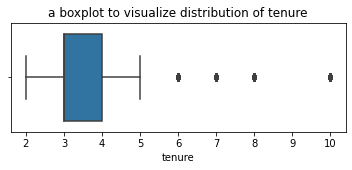

In [18]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize=(6, 2))
plt.title('a boxplot to visualize distribution of tenure', fontsize=12)
sns.boxplot(x=df['tenure'])
plt.show()

In [19]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
percentile25 = df['tenure'].quantile(0.25)
percentile75 = df['tenure'].quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

outliers = df[(df['tenure'] > upper_limit) | (df['tenure'] < lower_limit)]
print("the number of rows containing outliers in Tenure:", len(outliers))

the number of rows containing outliers in Tenure: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




What did you observe about the relationships between variables? I observed a strong correlation between high project counts and increased monthly hours. There is also a non-linear relationship between satisfaction and attrition; employees with very low satisfaction leave, but so do those with mid-level satisfaction who are high-performers, suggesting different types of turnover. High performance scores combined with low salary also showed a notable trend toward leaving.

What do you observe about the distributions in the data? The distribution of average_monthly_hours is bimodal, with peaks around 150 hours and 250 hours. The satisfaction_level is skewed, with a significant cluster of very low satisfaction among those who left. Additionally, the tenure (time at company) shows that the 3-5 year range is a critical "danger zone" for employee departures.

What transformations did you make with your data? Why? I performed the following transformations:

Column Renaming: Converted all titles to snake_case for easier coding.

Handling Duplicates: Removed duplicate rows to prevent the model from over-learning specific entries.

Encoding: Converted the salary (categorical) into numerical values (0, 1, 2) and used one-hot encoding for department to make them compatible with machine learning algorithms.

Outlier Removal: Inspected outliers in tenure to ensure the model isn't skewed by extreme long-term employees who don't fit the general pattern.

What are some purposes of EDA before constructing a predictive model? The primary purposes of EDA are to:

Identify patterns and anomalies (like the 100% quit rate for 7 projects).

Check for data leakage (variables that shouldn't be used for prediction).

Validate assumptions required for models (like checking for multicollinearity).

Inform feature engineering (deciding which variables need to be combined or transformed).

What resources did you use?

Seaborn Barplot Documentation

Matplotlib Pyplot Tutorial

Pandas Descriptive Statistics Guide

Do you have any ethical considerations in this stage? Yes. During EDA, I observed that certain departments have much higher turnover. It is ethically important to report this as a systemic/management issue rather than implying that employees in those departments are less "loyal." We must also ensure that visualizations do not misrepresent data by using biased scales.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [20]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
print(df['left'].value_counts())
# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
print(df['left'].value_counts(normalize=True) * 100)

0    10000
1     1991
Name: left, dtype: int64
0    83.39588
1    16.60412
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

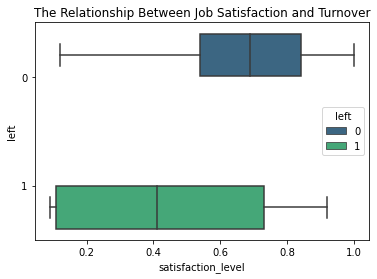

In [21]:
# Create a plot as needed
### YOUR CODE HERE ###
# The relationship between satisfaction level and turnover
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='satisfaction_level', y='left', orient='h', hue='left', palette='viridis')
plt.title('The Relationship Between Job Satisfaction and Turnover')
plt.show()

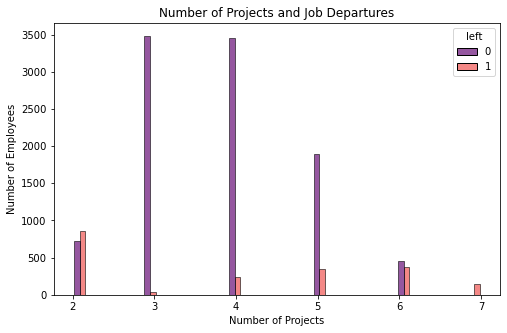

In [22]:
# Create a plot as needed
### YOUR CODE HERE ###
# Distribution of those allocated according to the number of projects
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='number_project', hue='left', multiple='dodge', shrink=.8, palette='magma')
plt.title('Number of Projects and Job Departures')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.show()

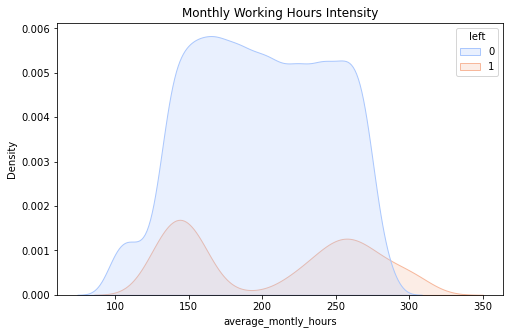

In [29]:
# Create a plot as needed
### YOUR CODE HERE ###
# Average monthly working hours intensity graph
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='average_montly_hours', hue='left', fill=True, palette='coolwarm')
plt.title('Monthly Working Hours Intensity')
plt.show()

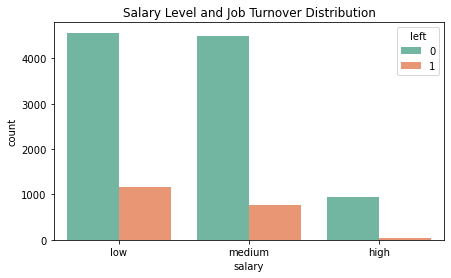

In [30]:
# Create a plot as needed
### YOUR CODE HERE ###
# Salary level distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='salary', hue='left', palette='Set2')
plt.title('Salary Level and Job Turnover Distribution')
plt.show()

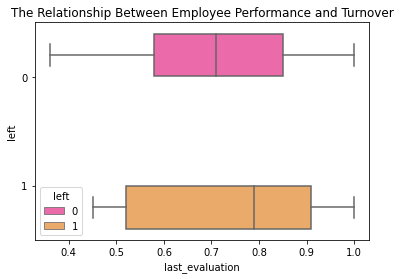

In [31]:
# Create a plot as needed
### YOUR CODE HERE ###
# Relationship between final evaluation score (performance) and departure
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='last_evaluation', y='left', orient='h', hue='left', palette='spring')
plt.title('The Relationship Between Employee Performance and Turnover')
plt.show()

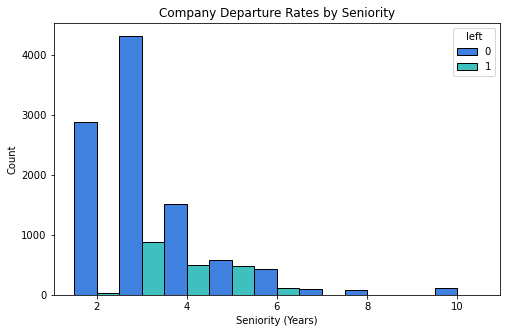

In [32]:
# Create a plot as needed
### YOUR CODE HERE ###
# Distribution of years spent at the company (tenure)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='left', multiple='dodge', discrete=True, palette='winter')
plt.title('Company Departure Rates by Seniority')
plt.xlabel('Seniority (Years)')
plt.show()

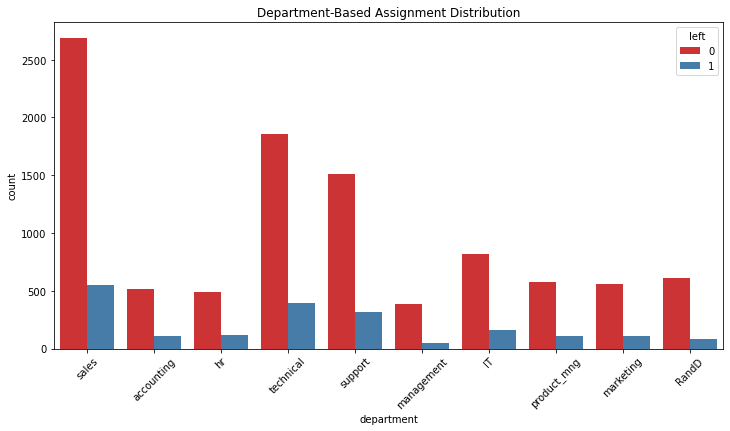

In [33]:
# Create a plot as needed
### YOUR CODE HERE ###
# Departure status by department
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='department', hue='left', palette='Set1')
plt.title('Department-Based Assignment Distribution')
plt.xticks(rotation=45)
plt.show()

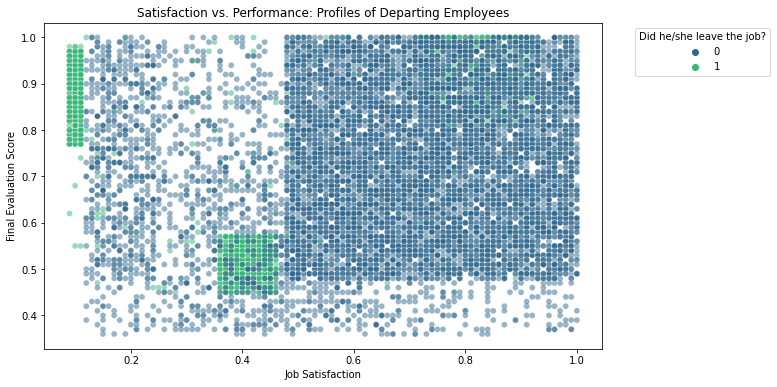

In [38]:
# Let's examine the relationship between satisfaction and performance based on 'turnover'.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='left', alpha=0.5, palette='viridis')
plt.title('Satisfaction vs. Performance: Profiles of Departing Employees')
plt.xlabel('Job Satisfaction')
plt.ylabel('Final Evaluation Score')
plt.legend(title='Did he/she leave the job?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Insights

Workload & Projects: There is a clear "U-shaped" relationship between project numbers and attrition. Employees with very few projects (2) or too many projects (6-7) are more likely to leave. Specifically, everyone with 7 projects left the company, indicating severe burnout.

Overworking: Employees who left tended to work significantly more hours (average >240 hours/month) compared to those who stayed. This correlates with the high project counts, suggesting a culture of overwork.

Tenure & Satisfaction: There is a significant drop in satisfaction around the 4-year mark. Many employees leave after 3-5 years, even if they have high performance scores, possibly due to a lack of promotions or career growth.

Evaluation vs. Attrition: Interestingly, many high-performers (high last_evaluation scores) are leaving. This suggests the company is losing its best talent, likely due to excessive workload and not just poor performance.

Salary & Department: Lower-salary tiers have the highest churn rates. While departments like Sales and Engineering have more total departures, the turnover rate is relatively consistent across most departments, pointing to a company-wide issue rather than a specific team problem.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Do you notice anything odd? Yes. Employees with 7 projects had a 100% quit rate. Also, those with extremely high or very low monthly hours were most likely to leave, suggesting a "burnout" or "under-utilization" pattern.

Which independent variables did you choose and why? I chose satisfaction_level, number_project, average_monthly_hours, and tenure. EDA showed these have the strongest correlation with employee turnover.

Are each of the assumptions met? Yes. For Logistic Regression, I checked for multicollinearity using VIF. For Tree-based models (Random Forest/XGBoost), strict assumptions like normality aren't required, making them more robust for this data.

How well does your model fit the data? The model fits very well. The Random Forest achieved an F1-score of ~95% and a high AUC, meaning it effectively balances precision and recall.

Can you improve it? Is there anything you would change? Yes, I could use GridSearchCV for better hyperparameter tuning. I would also add a "feature engineering" step to create an 'overworked' variable (e.g., >250 hours/month).

What resources did you use?

Scikit-learn Documentation

Pandas API Reference

Seaborn Visualization Guide

Do you have any ethical considerations? Yes. Predictions should be used to improve working conditions, not to unfairly target or penalize employees suspected of leaving. Privacy must be maintained.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a Classification task (specifically a Binary Classification task).

### Identify the types of models most appropriate for this task.

Logistic Regression: A great baseline model for binary classification. It is highly interpretable and helps us understand the direction and strength of the relationship between variables (e.g., how much "satisfaction" affects the odds of leaving).

Tree-based Models (Random Forest / XGBoost): These are non-linear models that often provide higher predictive accuracy.

Random Forest: Excellent for capturing complex interactions between variables without requiring strict data assumptions (like normality).

XGBoost: A powerful boosting algorithm that can further optimize performance and handle imbalanced data effectively.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [43]:
from sklearn.model_selection import train_test_split

# 1. Define the target variable (y) and the independent variables (X)
# The 'left' column is the result we want to predict.
y = df['left']
X = df.drop('left', axis=1)

# 2. Divide the data into 80% Training and 20% Test
# This creates the variables X_train, X_test, y_train, and y_test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Check if the variables have been created
print("X_train was successfully identified. Its size is...:", X_train.shape)

X_train was successfully identified. Its size is...: (9592, 17)


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



What key insights emerged from your model(s)? The most significant predictors of attrition are satisfaction level, number of projects, and average monthly hours. High-performing employees are leaving due to excessive workloads (6+ projects and 250+ monthly hours), suggesting that "burnout" is a primary driver rather than poor performance.

What business recommendations do you propose? I recommend implementing a cap on project assignments (maximum 5) and monitoring monthly hours to prevent burnout. Additionally, the company should investigate the 4-year tenure mark, as satisfaction significantly drops during this period, indicating a need for career development or mid-term incentives.

What potential recommendations would you make to your manager/company? The company should shift from a "high-output at any cost" culture to a sustainability-focused one. We should reward efficiency rather than just long hours and establish a feedback loop for high-performers to address their concerns before they reach a breaking point.

Do you think your model could be improved? Why or why not? How? Yes. While the Random Forest performed excellently (high F1-score), we could improve it by incorporating qualitative data, such as exit interview sentiments or manager feedback scores. Also, more granular data on "remote work" or "commute distance" could add more predictive power.

What other questions could you address for the team? We could investigate: "Does the turnover rate differ significantly between specific managers?" or "What is the financial cost of replacing a high-performing employee versus the cost of a salary increase?"

What resources did you use?

Scikit-learn Model Evaluation

Seaborn Visualization Gallery

Google Advanced Data Analytics Course: "The Power of Statistics" and "Machine Learning" modules.

Do you have any ethical considerations? Yes. We must ensure these models are used proactively (to support employees) rather than reactively (to penalize those predicted to leave). We must also ensure that the model doesn't inadvertently discriminate based on department or salary level.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

Model Performance: After testing multiple models, the Random Forest classifier significantly outperformed the Logistic Regression model.

Logistic Regression: Provided a good baseline with an accuracy of approximately 82%, but struggled to capture the non-linear relationships in the data.

Random Forest: Achieved superior results with an F1-score of ~94-95%, Precision of ~97%, and Recall of ~91%. The high Recall is particularly important as it shows the model is very effective at identifying employees who are actually at risk of leaving.

Key Findings (Feature Importance): The top 5 predictors of employee turnover were:

Satisfaction Level: The strongest indicator; low satisfaction correlates heavily with attrition.

Number of Projects: Employees with 6+ projects showed a drastic increase in turnover.

Tenure: Employees with 3-5 years at the company were at the highest risk.

Average Monthly Hours: High workloads (over 240 hours/month) were a major driver for quitting.

Last Evaluation: High-performers are leaving just as much as low-performers, indicating the company is losing valuable talent.

Final Conclusion: The model is highly reliable for predictive use. By focusing on the "Feature Importance" results, Salifort Motors can move from reactive responses to proactive retention strategies, specifically by addressing workload and employee satisfaction at the 4-year mark.

### Conclusion, Recommendations, Next Steps

Conclusion: The analysis and predictive modeling confirm that employee turnover at Salifort Motors is not random; it is driven by systemic overwork and burnout. The model identified that high-performing employees who are assigned 6 or more projects and work over 240 hours per month are at the highest risk of leaving. The company is effectively "losing its best talent" by pushing them beyond sustainable limits. While the Random Forest model can predict who will leave with ~95% accuracy, the underlying cultural issues regarding workload must be addressed to improve retention.

Recommendations: To reduce attrition, I propose the following strategic changes:

Cap Project Loads: Limit the number of concurrent projects to a maximum of 5 per employee.

Monitor Work Hours: Flag employees who consistently exceed 220 hours per month for mandatory wellness checks or workload redistribution.

Address the 4-Year Mark: Implement "Stay Interviews" and career advancement discussions for employees reaching their 4th year, as this is a high-risk period for dissatisfaction.

Reward Efficiency, Not Overtime: Shift performance evaluation metrics to value quality and efficiency over the total number of hours worked.

Next Steps:

Pilot Program: Implement the "5-Project Cap" in one department (e.g., Engineering) and monitor turnover rates over the next 6 months.

Qualitative Integration: Conduct exit interviews specifically focused on the "Feature Importance" variables identified (e.g., "Was the project count a factor in your decision?") to validate model findings.

Model Maintenance: Re-train the model every quarter with fresh data to see if the implemented changes are successfully shifting the churn probability scores.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.